_© 2025–2026 Ibrahim Malik. Released under the MIT License (see LICENSE)._

# 01 · Data Prep

1) **Raw EDA** on Intakes & Outcomes (shape, schema, missingness, basic plots)
2) **Preprocessing** (dogs only) create a merged dataset (intake -> nearest later outcome), then quick checks

> Datasets: Austin Animal Center Intakes & Outcomes (2013-10-01 to 2025-05-05).

_Ibrahim Malik, September 2025_  



In [1]:
# Imports

import os, sys
from pathlib import Path
import importlib
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Configure logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
log = logging.getLogger("prep")

# parent dir
sys.path.insert(0, os.path.abspath(".."))

# Importing data_preprocessing module
import src.data_preprocessing as dp
importlib.reload(dp)

# Importing specific functions from this module
from src.data_preprocessing import (
    load_intakes_csv,
    load_outcomes_csv,
    missing_summary,
    filter_dogs,
    parse_age_to_days,
    nearest_outcome_after_intake,
)

log.info("Current working directory: %s", os.getcwd())

INFO: Current working directory: C:\Users\ibrah\OneDrive\Desktop\6-project-capstone\notebooks


In [2]:
# Paths
# https://docs.python.org/3/library/pathlib.html

# snake_case lowercase for variables that may change
# All caps for constants
INTAKES_PATH = "../data/raw/aac_intakes.csv"
OUTCOMES_PATH = "../data/raw/aac_outcomes.csv"

FIG_DIR = "../figures"
PROC_DIR = "../data/processed"
DOCS_DIR = "../docs"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)

In [3]:
# Load raw CSVs
# https://docs.python.org/3/library/csv.html

intakes = load_intakes_csv(INTAKES_PATH)
outcomes = load_outcomes_csv(OUTCOMES_PATH)

log.info("Intakes shape: %s", intakes.shape)
log.info("Outcomes shape: %s", outcomes.shape)

display(intakes.head(3))
display(outcomes.head(3))

INFO: Intakes shape: (173812, 12)
INFO: Outcomes shape: (173775, 12)


,animal_id,name,intake_datetime,intake_monthyear,found_location,intake_type,intake_condition,animal_type,sex_upon_intake,age_upon_intake,breed,color
0,A521520,Nina,2013-10-01 07:51:00,2013-10-01,Norht Ec in Austin (TX),Stray,Normal,Dog,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664235,nan,2013-10-01 08:33:00,2013-10-01,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
2,A664236,nan,2013-10-01 08:33:00,2013-10-01,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White


,animal_id,date_of_birth,name,outcome_datetime,outcome_monthyear,outcome_type,outcome_subtype,animal_type,sex_upon_outcome,age_upon_outcome,breed,color
0,A668305,2012-01-12,nan,NaT,2013-12-01,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,nan,NaT,2014-02-01,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-03-04,nan,NaT,2014-04-01,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green


In [4]:
# Schema and missingness
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html

intakes_missing = missing_summary(intakes)
outcomes_missing = missing_summary(outcomes)

display(intakes_missing.head(15))
display(outcomes_missing.head(15))

# Save simple CSVs for report
intakes_missing.to_csv(f"{DOCS_DIR}/intakes_missing_summary.csv", index=False)
outcomes_missing.to_csv(f"{DOCS_DIR}/outcomes_missing_summary.csv", index=False)

,column,missing_frac,dtype,missing_pct
2,intake_datetime,0.600235,datetime64[ns],60.02
8,sex_upon_intake,0.000006,object,0.00
9,age_upon_intake,0.000000,object,0.00
0,animal_id,0.000000,object,0.00
7,animal_type,0.000000,object,0.00
10,breed,0.000000,object,0.00
11,color,0.000000,object,0.00
4,found_location,0.000000,object,0.00
6,intake_condition,0.000000,object,0.00
3,intake_monthyear,0.000000,datetime64[ns],0.00


,column,missing_frac,dtype,missing_pct
3,outcome_datetime,1.000000,datetime64[ns],100.00
6,outcome_subtype,0.541591,object,54.16
5,outcome_type,0.000265,object,0.03
9,age_upon_outcome,0.000052,object,0.01
8,sex_upon_outcome,0.000006,object,0.00
0,animal_id,0.000000,object,0.00
7,animal_type,0.000000,object,0.00
10,breed,0.000000,object,0.00
11,color,0.000000,object,0.00
1,date_of_birth,0.000000,datetime64[ns],0.00


In [5]:
# Focusing on dogs only for EDA

intakes_dogs = filter_dogs(intakes)
outcomes_dogs = filter_dogs(outcomes)

log.info("Dog intakes: %s, dog outcomes: %s", intakes_dogs.shape, outcomes_dogs.shape)

INFO: Dog intakes: (94608, 12), dog outcomes: (94505, 12)


In [6]:
ids_i = set(intakes_dogs["animal_id"].dropna().unique())
ids_o = set(outcomes_dogs["animal_id"].dropna().unique())

overlap = len(ids_i & ids_o)
log.info("ID overlap: %s / %s (%0.2f%%)", overlap, len(ids_i), 100*overlap/max(1,len(ids_i)))
log.info("Intake time range: %s to %s", intakes_dogs["intake_datetime"].min(), intakes_dogs["intake_datetime"].max())
log.info("Outcome time range: %s to %s", outcomes_dogs["outcome_datetime"].min(), outcomes_dogs["outcome_datetime"].max())

INFO: ID overlap: 79742 / 80211 (99.42%)
INFO: Intake time range: 2013-10-01 07:51:00 to 2025-05-04 22:55:00
INFO: Outcome time range: NaT to NaT


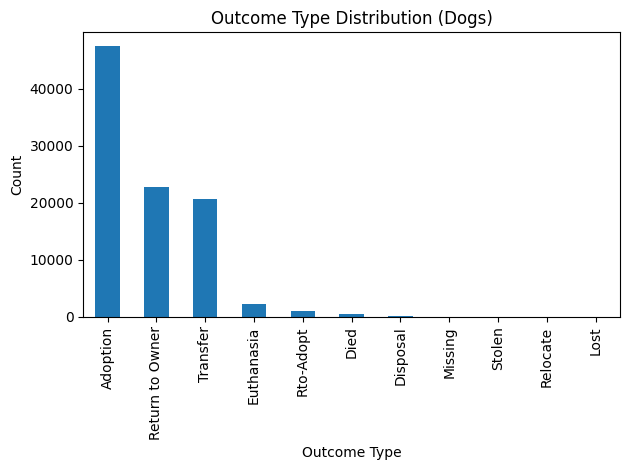

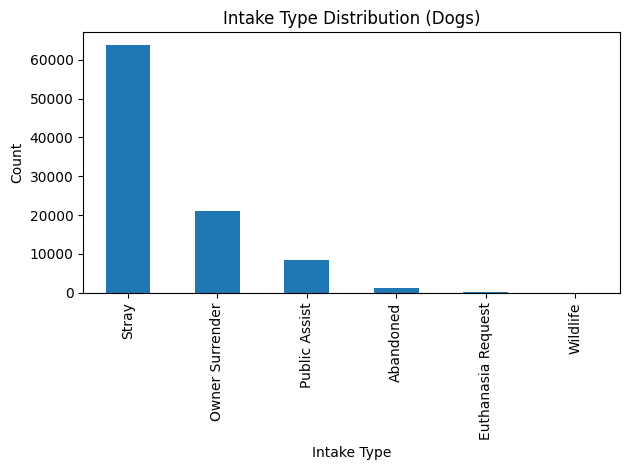

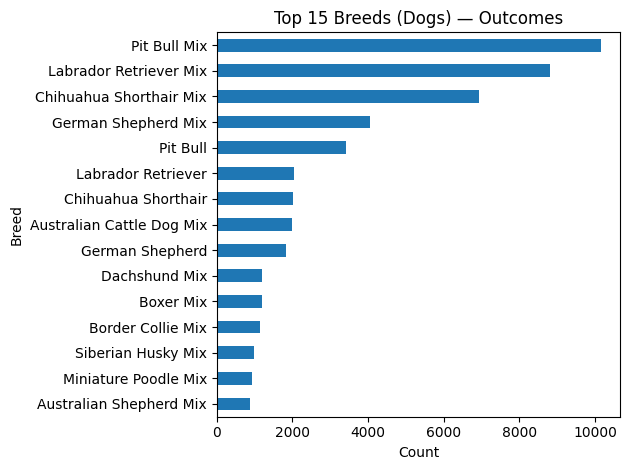

In [7]:
# Basic distributions
# Outcome and intake types
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

# Outcome types (dogs)
ax = outcomes_dogs["outcome_type"].value_counts().head(15).plot(kind="bar")
ax.set_title("Outcome Type Distribution (Dogs)"); ax.set_xlabel("Outcome Type"); ax.set_ylabel("Count")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/dogs_outcome_type_bar.png", bbox_inches="tight"); plt.show()

# Intake types (dogs)
ax = intakes_dogs["intake_type"].value_counts().head(15).plot(kind="bar")
ax.set_title("Intake Type Distribution (Dogs)"); ax.set_xlabel("Intake Type"); ax.set_ylabel("Count")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/dogs_intake_type_bar.png", bbox_inches="tight"); plt.show()

# Top breeds
ax = outcomes_dogs["breed"].value_counts().head(15).iloc[::-1].plot(kind="barh")
ax.set_title("Top 15 Breeds (Dogs) — Outcomes"); ax.set_xlabel("Count"); ax.set_ylabel("Breed")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/dogs_top_breeds_bar.png", bbox_inches="tight"); plt.show()

In [8]:
log.info("dtypes: intake=%s outcome=%s", intakes_dogs["intake_datetime"].dtype, outcomes_dogs["outcome_datetime"].dtype)
log.info("NaT in intake_datetime (will be dropped inside function): %s", intakes_dogs["intake_datetime"].isna().sum())

INFO: dtypes: intake=datetime64[ns] outcome=datetime64[ns]
INFO: NaT in intake_datetime (will be dropped inside function): 56347


In [9]:
# Sanity check, do any dogs have out of order dates?
# Inspired by https://stackoverflow.com/questions/4983258/check-list-monotonicity

def _check_monotonic(df, by, on):
    g = df.dropna(subset=[by, on]).sort_values([by, on], kind="mergesort")

    # robust: explicitly compute if any decrease occurs per group
    def _non_monotonic(s: pd.Series) -> bool:
        # ensure datetime
        ss = pd.to_datetime(s, errors="coerce")
        diffs = ss.diff()
        return bool((diffs < pd.Timedelta(0)).any())

    flags = g.groupby(by, sort=False)[on].agg(_non_monotonic).astype(bool)
    num_bad = int(flags.sum())
    print("Non-monotonic groups:", num_bad)
    if num_bad:
        print("Example bad animal_ids:", list(flags[flags].index[:5]))
    return num_bad

log.info("INTAKES:")
_ = _check_monotonic(intakes_dogs, "animal_id", "intake_datetime")
log.info("OUTCOMES:")
_ = _check_monotonic(outcomes_dogs, "animal_id", "outcome_datetime")

INFO: INTAKES:
INFO: OUTCOMES:


Non-monotonic groups: 0
Non-monotonic groups: 0


In [10]:
# How many rows have usable datetime vs month-year fields?
def coverage(df, dt_col, my_col, label):
    log.info("%s: rows=%s | %s non-null=%s | %s non-null=%s",
             label, f"{len(df):,}",
             dt_col, df[dt_col].notna().sum(),
             my_col, df[my_col].notna().sum())

coverage(intakes_dogs, "intake_datetime", "intake_monthyear", "INTAKES (dogs)")
coverage(outcomes_dogs, "outcome_datetime", "outcome_monthyear", "OUTCOMES (dogs)")

INFO: INTAKES (dogs): rows=94,608 | intake_datetime non-null=38261 | intake_monthyear non-null=94608
INFO: OUTCOMES (dogs): rows=94,505 | outcome_datetime non-null=0 | outcome_monthyear non-null=94505


In [11]:
# Load raw CSVs as strings (unparsed)
raw_i = pd.read_csv(INTAKES_PATH, dtype=str).rename(columns=dp.INTAKES_RENAME)
raw_o = pd.read_csv(OUTCOMES_PATH, dtype=str).rename(columns=dp.OUTCOMES_RENAME)

# Which parsed rows are NaT?
bad_i_idx = intakes_dogs.index[intakes_dogs["intake_datetime"].isna()][:20]
bad_o_idx = outcomes_dogs.index[outcomes_dogs["outcome_datetime"].isna()][:20]

print("Example raw INTakes DateTime strings that failed to parse:")
display(raw_i.loc[bad_i_idx, ["intake_datetime","intake_monthyear"]])

print("Example raw OUTcomes DateTime strings that failed to parse:")
display(raw_o.loc[bad_o_idx, ["outcome_datetime","outcome_monthyear","date_of_birth","age_upon_outcome"]])

Example raw INTakes DateTime strings that failed to parse:


,intake_datetime,intake_monthyear
612,10/13/2013 09:48:00 AM,Oct-13
616,10/13/2013 10:43:00 AM,Oct-13
617,10/13/2013 11:02:00 AM,Oct-13
618,10/13/2013 11:02:00 AM,Oct-13
623,10/13/2013 11:16:00 AM,Oct-13
624,10/13/2013 11:34:00 AM,Oct-13
625,10/13/2013 11:42:00 AM,Oct-13
628,10/13/2013 12:25:00 PM,Oct-13
629,10/13/2013 12:35:00 PM,Oct-13
632,10/13/2013 01:41:00 PM,Oct-13


Example raw OUTcomes DateTime strings that failed to parse:


,outcome_datetime,outcome_monthyear,date_of_birth,age_upon_outcome
12,2014-07-11T00:00:00-05:00,Jul-14,22/04/2014,2 months
21,2014-12-23T00:00:00-05:00,Dec-14,14/12/2013,1 year
23,2014-12-27T00:00:00-05:00,Dec-14,22/04/2014,8 months
26,2014-12-31T00:00:00-05:00,Dec-14,02/01/2009,5 years
27,2015-01-01T00:00:00-05:00,Jan-15,27/12/2008,6 years
30,2015-01-08T00:00:00-05:00,Jan-15,24/12/2013,1 year
31,2015-01-12T00:00:00-05:00,Jan-15,31/08/2011,3 years
32,2015-01-12T00:00:00-05:00,Jan-15,07/01/2012,3 years
34,2015-01-12T00:00:00-05:00,Jan-15,08/01/2012,3 years
35,2015-01-12T00:00:00-05:00,Jan-15,08/09/2008,6 years


In [12]:
# sanity check to see if known string as seen above works for datetime parsing
pd.to_datetime("2015-01-12T00:00:00-05:00", utc=True)

Timestamp('2015-01-12 05:00:00+0000', tz='UTC')

INFO: Intakes matched to a later outcome (≤365d): 98.96%


count    93624.000000
mean        36.459868
std         37.422023
min         12.503472
25%         20.000000
50%         20.000000
75%         50.000000
max        359.809028
Name: days_to_outcome, dtype: float64

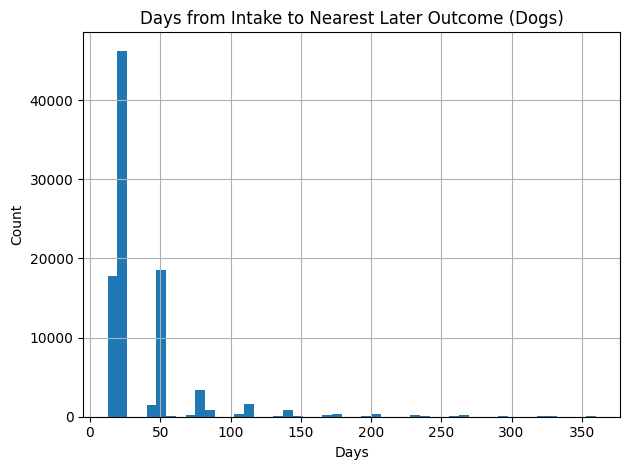

INFO: Saved full merged dataset -> ../data/processed/merged_dataset.csv (rows=94,608, cols=28)


In [13]:
# Validate merge strategy
# Intake to nearest later outcome by animal_id

merged_preview = nearest_outcome_after_intake(intakes_dogs, outcomes_dogs, max_days=365)

matched_frac = merged_preview["match_time_outcome"].notna().mean()
log.info("Intakes matched to a later outcome (≤365d): %.2f%%", 100*matched_frac)

delta_days = merged_preview["days_to_outcome"]
display(delta_days.describe())

# Histogram
delta_days.dropna().clip(-10, 365).hist(bins=50)
plt.title("Days from Intake to Nearest Later Outcome (Dogs)")
plt.xlabel("Days"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/days_to_outcome_hist.png", bbox_inches="tight"); plt.show()

# Save
merged_preview.head(10000).to_csv(f"{PROC_DIR}/intake_outcome_nearest_merge_sample.csv", index=False)
merged_preview.to_csv(f"{PROC_DIR}/merged_dataset.csv", index=False)
log.info("Saved full merged dataset -> %s (rows=%s, cols=%s)", f"{PROC_DIR}/merged_dataset.csv",
         f"{len(merged_preview):,}", merged_preview.shape[1])

In [14]:
# Intake match-time monotonic per animal_id
ok_i = merged_preview.groupby("animal_id", sort=False)["match_time_intake"].apply(lambda s: s.is_monotonic_increasing).all()

# Outcome match-time monotonic per animal_id
ok_o = outcomes_dogs.assign(
    match_time_outcome = pd.to_datetime(outcomes_dogs["outcome_datetime"], errors="coerce")
).groupby("animal_id", sort=False)["match_time_outcome"].apply(lambda s: s.is_monotonic_increasing).all()

ok_i, ok_o

(True, False)

In [15]:
total = len(merged_preview)
log.info("Rows: %s", total)
log.info("Time source intake: %s", merged_preview["time_source_intake"].value_counts(dropna=False).to_dict())
log.info("Time source outcome: %s", merged_preview["time_source_outcome"].value_counts(dropna=False).to_dict())
log.info("Match rate (any time source): %.4f", merged_preview["match_time_outcome"].notna().mean())

INFO: Rows: 94608
INFO: Time source intake: {'monthyear_d5': 56347, 'datetime': 38261}
INFO: Time source outcome: {'monthyear_d25': 93624, nan: 984}
INFO: Match rate (any time source): 0.9896


,owner_surrender_rate
age_bin_intake,
<3mo,0.224309
3-12mo,0.221228
1-3y,0.200541
3-7y,0.256982
7y+,0.231936


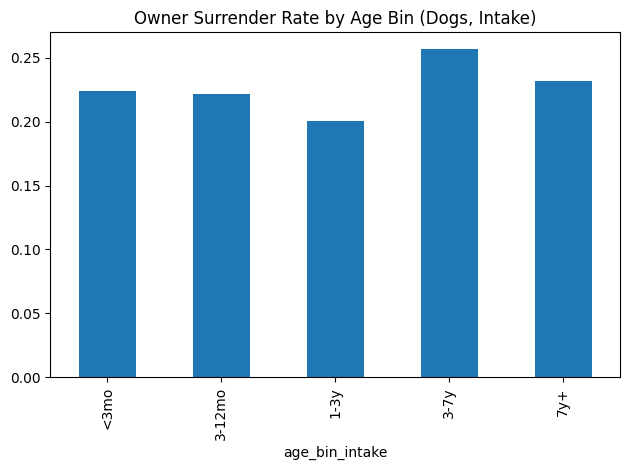

In [16]:
# Age bins vs owner-surrender proxy

tmp = intakes_dogs.copy()
tmp["age_days_intake"] = tmp["age_upon_intake"].apply(parse_age_to_days)

# simple age bins
bins = [-1, 90, 365, 3*365, 7*365, float("inf")]
labels = ["<3mo", "3-12mo", "1-3y", "3-7y", "7y+"]
tmp["age_bin_intake"] = pd.cut(tmp["age_days_intake"], bins=bins, labels=labels)

tmp["owner_surrender"] = tmp["intake_type"].str.lower().eq("owner surrender")
rate_by_bin = tmp.groupby("age_bin_intake")["owner_surrender"].mean().rename("owner_surrender_rate")

display(rate_by_bin.to_frame())

rate_by_bin.plot(kind="bar", title="Owner Surrender Rate by Age Bin (Dogs, Intake)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/owner_surrender_rate_by_agebin.png", bbox_inches="tight"); plt.show()

In [17]:
# Labelling 
# np.searchsorted per animal with progress for monitoring
# This part is essential for modelling done in 02_modelling_and_evaluation.ipynb

PROC_DIR = "../data/processed"
merged = pd.read_csv(
    f"{PROC_DIR}/merged_dataset.csv",
    parse_dates=["match_time_intake","match_time_outcome"],
    low_memory=False
)

# Dogs only + clean ids
merged["animal_id"] = merged["animal_id"].astype(str).str.strip().str.upper()
if "animal_type_intake" in merged.columns:
    merged = merged[merged["animal_type_intake"].str.lower() == "dog"].copy()

# Ensure datetime
merged["match_time_intake"] = pd.to_datetime(merged["match_time_intake"], errors="coerce")
merged["match_time_outcome"] = pd.to_datetime(merged["match_time_outcome"], errors="coerce")

# Build intake timelines per animal (numpy arrays)
intakes_tbl = (
    merged[["animal_id","match_time_intake","intake_type_intake"]]
    .rename(columns={"match_time_intake":"intake_time","intake_type_intake":"intake_type"})
    .dropna(subset=["animal_id","intake_time"])
)

# Pre-group
intake_dict = {}
for aid, g in intakes_tbl.groupby("animal_id", sort=False):
    ti = g["intake_time"].to_numpy()
    tt = g["intake_type"].astype(object).to_numpy()
    order = np.argsort(ti, kind="mergesort")
    intake_dict[aid] = (ti[order], tt[order])

# Outcomes to label
outcomes_df = (
    merged[["animal_id","match_time_outcome"]]
    .dropna(subset=["animal_id","match_time_outcome"])
    .reset_index(names="orig_row")
)

# Prepare result holders
next_time = pd.Series(pd.NaT, index=outcomes_df.index, dtype="datetime64[ns]")
next_type = pd.Series(pd.NA,  index=outcomes_df.index, dtype="object")

# Vectorized per-animal lookup with progress
uids = outcomes_df["animal_id"].unique()
for i, aid in enumerate(uids, 1):
    if i % 2000 == 0 or i == len(uids):
        log.info("processed %d/%d animals", i, len(uids))
    to_g = outcomes_df[outcomes_df["animal_id"] == aid]
    if aid not in intake_dict:
        continue
    ti, tt = intake_dict[aid]  # numpy arrays, sorted by time
    if ti.size == 0:
        continue
    to = to_g["match_time_outcome"].to_numpy()
    pos = np.searchsorted(ti, to, side="right")  # strictly after outcome
    valid = (pos >= 0) & (pos < ti.size)
    idx = to_g.index.to_numpy()
    # https://stackoverflow.com/questions/55874138/does-loc-in-pandas-use-vectorised-logic-or-a-for-loop
    next_time.loc[idx[valid]] = ti[pos[valid]]
    next_type.loc[idx[valid]] = tt[pos[valid]]

# Attach back to merged by original row
merged["next_intake_time"] = pd.NaT
merged["next_intake_type"] = pd.Series(pd.NA, index=merged.index, dtype="object")
merged.loc[outcomes_df["orig_row"], "next_intake_time"] = next_time.values
merged.loc[outcomes_df["orig_row"], "next_intake_type"] = next_type.values

# Build labels
WINDOW_DAYS = 365
LEFT_OUTCOMES = {"Adoption","Transfer","Rto-Adopt","Return to Owner"}  # Can tune

dt_days = (merged["next_intake_time"] - merged["match_time_outcome"]).dt.total_seconds() / 86400.0
left_mask = merged["outcome_type_outcome"].isin(LEFT_OUTCOMES)

merged["abandoned_365"] = (
    left_mask & merged["next_intake_time"].notna() & (dt_days >= 0) & (dt_days <= WINDOW_DAYS)
).astype(int)

REASON_MAP = {
    "Owner Surrender": "owner_surrender",
    "Stray": "stray",
    "Public Assist": "public_assist",
    "Confiscate": "confiscate",
    "Wildlife": "wildlife",
}
mapped_reason = merged["next_intake_type"].map(REASON_MAP)
merged["abandon_reason"] = np.where(
    merged["next_intake_time"].notna(), mapped_reason.fillna("other"), "no_return"
)

# Minimal modeling table
keep_cols = [
    "animal_id",
    "match_time_intake","match_time_outcome","next_intake_time",
    "abandoned_365","abandon_reason",
    "intake_type_intake","intake_condition_intake","sex_upon_intake_intake",
    "age_upon_intake_intake","breed_intake","color_intake",
]
model_df = merged[keep_cols].copy()

log.info("Rows: %s", len(model_df))
log.info("Abandonment positive rate: %.4f", model_df["abandoned_365"].mean())
log.info("Reason counts (top):\n%s", model_df["abandon_reason"].value_counts().head().to_string())

out_path = Path(PROC_DIR) / "ready_for_ml.csv"
model_df.to_csv(out_path, index=False)
log.info("Saved -> %s", out_path)

INFO: processed 2000/79421 animals
INFO: processed 4000/79421 animals
INFO: processed 6000/79421 animals
INFO: processed 8000/79421 animals
INFO: processed 10000/79421 animals
INFO: processed 12000/79421 animals
INFO: processed 14000/79421 animals
INFO: processed 16000/79421 animals
INFO: processed 18000/79421 animals
INFO: processed 20000/79421 animals
INFO: processed 22000/79421 animals
INFO: processed 24000/79421 animals
INFO: processed 26000/79421 animals
INFO: processed 28000/79421 animals
INFO: processed 30000/79421 animals
INFO: processed 32000/79421 animals
INFO: processed 34000/79421 animals
INFO: processed 36000/79421 animals
INFO: processed 38000/79421 animals
INFO: processed 40000/79421 animals
INFO: processed 42000/79421 animals
INFO: processed 44000/79421 animals
INFO: processed 46000/79421 animals
INFO: processed 48000/79421 animals
INFO: processed 50000/79421 animals
INFO: processed 52000/79421 animals
INFO: processed 54000/79421 animals
INFO: processed 56000/79421 anim

**END**